# Link Prediction — Multi-Seeds Pipeline
Chaque section correspond à une étape indépendante. La boucle multi-seeds est encapsulée dans `run_one_seed()` (cellule 10) et appelée dans la cellule 11.

In [4]:
import os, json, random
import numpy as np
import pandas as pd
import networkx as nx
import torch
import torch.nn as nn
import torch.nn.functional as F

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    accuracy_score, f1_score, classification_report,
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler


#Config

In [5]:
SEEDS           = [42, 43, 44, 45, 46]
MASTER_SEED     = 42
DEVICE          = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# Move task1/X files in Colab filesystem (using the cell below) if using colab, and change paths
NODES_PATH      = "nodes.csv"
EDGES_PATH      = "edges.csv"
OUTPUT_DIR      = "task2/outputs_task2_multimodel"
TARGET_RELATION = "containsGameElement"
NEGATIVE_RATIO  = 2
TOP_K           = 5

os.makedirs(OUTPUT_DIR, exist_ok=True)
print("Device:", DEVICE)

Device: cuda


In [6]:
import ipywidgets as widgets
from IPython.display import display
import io, os, zipfile, pandas as pd

_uploaded = {}

uploader = widgets.FileUpload(multiple=True, accept=".csv,.json,.pkl,.pt,.ipynb,.zip,.txt")
out = widgets.Output()

def _on_upload(change):
    for name, meta in uploader.value.items():
        raw = meta["content"] if isinstance(meta, dict) else bytes(meta)
        if name.endswith(".zip"):
            with zipfile.ZipFile(io.BytesIO(raw)) as z:
                z.extractall(".")
                members = z.namelist()
            with out:
                print(f"extracted: {name} -> {members}")
            for m in members:
                if os.path.isfile(m):
                    with open(m, "rb") as f:
                        _uploaded[os.path.basename(m)] = f.read()
        else:
            _uploaded[name] = raw
            with open(name, "wb") as f:
                f.write(raw)
            with out:
                print(f"saved: {name} ({len(raw)} bytes)")

uploader.observe(_on_upload, names="value")
display(uploader, out)

def get_df(filename):
    if filename in _uploaded:
        return pd.read_csv(io.BytesIO(_uploaded[filename]))
    return pd.read_csv(filename)

FileUpload(value={}, accept='.csv,.json,.pkl,.pt,.ipynb,.zip,.txt', description='Upload', multiple=True)

Output()

## 1. Chargement des données

In [7]:
nodes = pd.read_csv(NODES_PATH)
edges = pd.read_csv(EDGES_PATH)

nodes["id"]      = nodes["id"].astype(str).str.strip()
edges["source"]  = edges["source"].astype(str).str.strip()
edges["target"]  = edges["target"].astype(str).str.strip()
nodes["primary_type"] = nodes["primary_type"].fillna("unknown").astype(str)

assert not ({"id","label","primary_type"} - set(nodes.columns)), "Colonnes manquantes dans nodes.csv"
assert not ({"source","target","relation"} - set(edges.columns)), "Colonnes manquantes dans edges.csv"

print("nodes:", nodes.shape)
print("edges:", edges.shape)
display(nodes.head(3))
display(edges.head(3))

nodes: (480, 8)
edges: (653, 6)


,id,label,primary_type,type_count,out_degree,in_degree,hub_score,authority_score
0,http://org.semanticweb.owlapi/error#Error1,Error1,Class,1,0,3,0.0,1.0
1,http://org.semanticweb.owlapi/error#Error2,Error2,Class,1,0,3,0.0,1.0
2,http://org.semanticweb.owlapi/error#Error3,Error3,Class,1,1,1,0.5,0.5


,source,target,relation,weight,symmetric,transitive
0,Error3,Kind,subClassOf,0.548387,0,0
1,isbn,identifier,subPropertyOf,0.145161,0,0
2,isbn,isbn,subPropertyOf,0.145161,0,0


## 2. Construction des graphes

In [8]:
def build_graph(nodes_df, edges_df, exclude_relation=None):
    G = nx.DiGraph()
    label_set = set(nodes_df["label"])
    for _, row in nodes_df.iterrows():
        G.add_node(row["label"], label=row["label"],
                   type=row.get("primary_type","unknown"), iri=row.get("id",""))
    for _, row in edges_df.iterrows():
        src, tgt = row["source"], row["target"]
        rel = str(row["relation"]).strip()
        if src in label_set and tgt in label_set:
            if exclude_relation is None or rel != exclude_relation.strip():
                G.add_edge(src, tgt, relation=rel)
    return G

In [9]:
G_full = build_graph(nodes, edges)
G_mp   = build_graph(nodes, edges, exclude_relation=TARGET_RELATION)

In [10]:
print(f"G_full  — nodes: {G_full.number_of_nodes()} | edges: {G_full.number_of_edges()}")
print(f"G_mp    — nodes: {G_mp.number_of_nodes()}   | edges: {G_mp.number_of_edges()}")

G_full  — nodes: 459 | edges: 607
G_mp    — nodes: 459   | edges: 587


## 3. Construction du dataset (paires positives / négatives)

In [11]:
positive_edges = (
    edges[edges["relation"] == TARGET_RELATION][["source","target"]]
    .drop_duplicates().reset_index(drop=True)
)
design_practices = sorted(positive_edges["source"].unique())
game_elements    = sorted(positive_edges["target"].unique())
positive_set     = set(map(tuple, positive_edges.values))

all_candidate_pairs = [(dp, ge) for dp in design_practices
                                 for ge in game_elements if dp != ge]
negative_candidates = [p for p in all_candidate_pairs if p not in positive_set]

rng = random.Random(MASTER_SEED)
rng.shuffle(negative_candidates)

n_negative = min(len(negative_candidates), len(positive_edges) * NEGATIVE_RATIO)
neg_df = pd.DataFrame(negative_candidates[:n_negative], columns=["source","target"])
neg_df["label"] = 0

pos_df = positive_edges.copy()
pos_df["label"] = 1


In [12]:
dataset = (pd.concat([pos_df, neg_df], ignore_index=True)
             .sample(frac=1, random_state=MASTER_SEED)
             .reset_index(drop=True))

In [13]:
print("Dataset shape:", dataset.shape)
print(dataset["label"].value_counts())
print(f"design practices: {len(design_practices)} | game elements: {len(game_elements)}")

Dataset shape: (60, 3)
label
0    40
1    20
Name: count, dtype: int64
design practices: 15 | game elements: 6


## 4. Features de nœuds (calculées une seule fois)

In [14]:
node_ids    = list(G_mp.nodes())
node_to_idx = {node: idx for idx, node in enumerate(node_ids)}
idx_to_node = {idx: node for node, idx in node_to_idx.items()}

degree_centrality = nx.degree_centrality(G_mp)
pagerank = nx.pagerank(G_mp) if G_mp.number_of_edges() > 0 else {n: 0.0 for n in node_ids}

node_types = sorted({
    str(G_full.nodes[n].get("type","unknown")) if G_full.nodes[n].get("type") is not None else "unknown"
    for n in G_full.nodes()
})

feature_rows = []
for node in node_ids:
    node_type = G_mp.nodes[node].get("type","unknown")
    row = {
        "in_degree":         G_mp.in_degree(node),
        "out_degree":        G_mp.out_degree(node),
        "degree_centrality": degree_centrality.get(node, 0.0),
        "pagerank_context":  pagerank.get(node, 0.0),
    }
    for t in node_types:
        row[f"type_{t}"] = 1.0 if node_type == t else 0.0
    feature_rows.append(row)

node_features_df = pd.DataFrame(feature_rows, index=node_ids)
numeric_cols = ["in_degree","out_degree","degree_centrality","pagerank_context"]
node_features_df[numeric_cols] = StandardScaler().fit_transform(node_features_df[numeric_cols])

X_nodes_np = node_features_df.values.astype(np.float32)
X_nodes    = torch.tensor(X_nodes_np, dtype=torch.float32).to(DEVICE)
print("X_nodes:", X_nodes.shape)
display(node_features_df.head(3))

X_nodes: torch.Size([459, 11])


,in_degree,out_degree,degree_centrality,pagerank_context,type_AnnotationProperty,type_Class,type_DatatypeProperty,type_NamedIndividual,type_ObjectProperty,type_Ontology,type_unknown
Error1,0.459410,-1.131540,0.117497,0.061964,0.0,1.0,0.0,0.0,0.0,0.0,0.0
Error2,0.459410,-1.131540,0.117497,-0.035863,0.0,1.0,0.0,0.0,0.0,0.0,0.0
Error3,-0.074436,-0.246741,-0.148173,-0.158147,0.0,1.0,0.0,0.0,0.0,0.0,0.0


## 5. Matrice d'adjacence normalisée

In [15]:
num_nodes = len(node_ids)
adj = torch.zeros((num_nodes, num_nodes), dtype=torch.float32)
for u, v in G_mp.edges():
    if u in node_to_idx and v in node_to_idx:
        i, j = node_to_idx[u], node_to_idx[v]
        adj[i, j] = 1.0
        adj[j, i] = 1.0
adj     += torch.eye(num_nodes)
adj_norm = (adj / adj.sum(dim=1, keepdim=True).clamp(min=1.0)).to(DEVICE)
print("adj_norm:", adj_norm.shape)

adj_norm: torch.Size([459, 459])


## 6. Fonctions d'heuristiques et de features paires

In [16]:
G_undirected = G_mp.to_undirected()
# Pré-calcul du clustering (coûteux, fait une seule fois)
_clustering_cache = None

def _get_clustering():
    global _clustering_cache
    if _clustering_cache is None:
        _clustering_cache = nx.clustering(G_undirected)
    return _clustering_cache

def compute_graph_heuristics(u, v):
    try:    aa = next(nx.adamic_adar_index(G_undirected, [(u,v)]))[2]
    except: aa = 0.0
    try:    jc = next(nx.jaccard_coefficient(G_undirected, [(u,v)]))[2]
    except: jc = 0.0
    try:    pa = next(nx.preferential_attachment(G_undirected, [(u,v)]))[2]
    except: pa = 0.0
    try:    cn = len(list(nx.common_neighbors(G_undirected, u, v)))
    except: cn = 0

    # Shortest path
    try:    sp = nx.shortest_path_length(G_undirected, u, v)
    except: sp = 999

    # Common 2nd-degree neighbors
    neighbors_u = set(G_undirected.neighbors(u))
    neighbors_v = set(G_undirected.neighbors(v))
    n2_u = set(n for nb in neighbors_u for n in G_undirected.neighbors(nb)) - {u}
    n2_v = set(n for nb in neighbors_v for n in G_undirected.neighbors(nb)) - {v}
    cn2 = len(n2_u & n2_v)

    # Resource Allocation index
    try:    ra = next(nx.resource_allocation_index(G_undirected, [(u,v)]))[2]
    except: ra = 0.0

    # Clustering coefficients
    cc = _get_clustering()
    cc_u = cc.get(u, 0.0)
    cc_v = cc.get(v, 0.0)

    # Absolute PageRank difference
    pr_diff = abs(pagerank.get(u, 0.0) - pagerank.get(v, 0.0))

    return np.array([aa, jc, pa, cn, sp, cn2, ra, cc_u, cc_v, pr_diff], dtype=np.float32)


In [17]:
def build_heuristic_features(df):
    return np.vstack([
        compute_graph_heuristics(r["source"], r["target"])
        for _, r in df.iterrows()
    ]).astype(np.float32)

In [18]:
def build_pair_features(df):
    # Pré-calcul du mapping type
    type_map = dict(zip(nodes["label"], nodes["primary_type"]))
    # Pré-calcul du label-encoding des paires de types
    type_pairs = sorted({
        f"{type_map.get(r['source'],'?')}_{type_map.get(r['target'],'?')}"
        for _, r in df.iterrows()
    })
    type_pair_to_idx = {tp: idx for idx, tp in enumerate(type_pairs)}

    feats = []
    for _, r in df.iterrows():
        src  = X_nodes_np[node_to_idx[r["source"]]]
        dst  = X_nodes_np[node_to_idx[r["target"]]]
        heur = compute_graph_heuristics(r["source"], r["target"])

        # Features sémantiques
        same_type = float(type_map.get(r["source"]) == type_map.get(r["target"]))
        tp_key    = f"{type_map.get(r['source'],'?')}_{type_map.get(r['target'],'?')}"
        type_pair_feat = np.zeros(len(type_pair_to_idx), dtype=np.float32)
        type_pair_feat[type_pair_to_idx[tp_key]] = 1.0

        feats.append(np.concatenate([
            src, dst, np.abs(src-dst), src*dst,
            heur,
            np.array([same_type], dtype=np.float32),
            type_pair_feat,
        ]))
    return np.vstack(feats)


In [19]:
def dataframe_to_link_tensors(df):
    src = torch.tensor([node_to_idx[n] for n in df["source"]], dtype=torch.long,    device=DEVICE)
    dst = torch.tensor([node_to_idx[n] for n in df["target"]], dtype=torch.long,    device=DEVICE)
    y   = torch.tensor(df["label"].values,                     dtype=torch.float32,  device=DEVICE)
    return src, dst, y

print("Fonctions d'heuristiques et de features OK")

Fonctions d'heuristiques et de features OK


## 7. Définition des modèles PyTorch

##GCN

In [20]:
class GCNLayer(nn.Module):
    def __init__(self, in_dim, out_dim):
        super().__init__()
        self.linear = nn.Linear(in_dim, out_dim)
    def forward(self, x, adj_norm):
        return F.relu(self.linear(torch.matmul(adj_norm, x)))


In [21]:
class GCNEncoder(nn.Module):
    def __init__(self, in_dim, hidden_dim=32, embedding_dim=16, dropout=0.5):
        super().__init__()
        self.layer1  = GCNLayer(in_dim, hidden_dim)
        self.layer2  = GCNLayer(hidden_dim, embedding_dim)
        self.dropout = nn.Dropout(dropout)
    def forward(self, x, adj_norm):
        return self.layer2(self.dropout(self.layer1(x, adj_norm)), adj_norm)

In [22]:
class GCNLinkPredictionModel(nn.Module):
    def __init__(self, in_dim, hidden_dim=32, embedding_dim=16):
        super().__init__()
        self.encoder = GCNEncoder(in_dim, hidden_dim, embedding_dim)
        self.decoder = LinkDecoder(embedding_dim, heuristic_dim=10)
    def forward(self, x, adj_norm, src_idx, dst_idx, heuristics):
        z = self.encoder(x, adj_norm)
        return self.decoder(z[src_idx], z[dst_idx], heuristics)

In [ ]:
##GraphSAGE

In [23]:
class GraphSAGELayer(nn.Module):
    def __init__(self, in_dim, out_dim):
        super().__init__()
        self.self_linear  = nn.Linear(in_dim, out_dim)
        self.neigh_linear = nn.Linear(in_dim, out_dim)
    def forward(self, x, adj_norm):
        return F.relu(self.self_linear(x) + self.neigh_linear(torch.matmul(adj_norm, x)))

In [24]:
class GraphSAGEEncoder(nn.Module):
    def __init__(self, in_dim, hidden_dim=32, embedding_dim=16, dropout=0.5):
        super().__init__()
        self.layer1  = GraphSAGELayer(in_dim, hidden_dim)
        self.layer2  = GraphSAGELayer(hidden_dim, embedding_dim)
        self.dropout = nn.Dropout(dropout)
    def forward(self, x, adj_norm):
        return self.layer2(self.dropout(self.layer1(x, adj_norm)), adj_norm)

In [25]:
class GraphSAGELinkPredictionModel(nn.Module):
    def __init__(self, in_dim, hidden_dim=32, embedding_dim=16):
        super().__init__()
        self.encoder = GraphSAGEEncoder(in_dim, hidden_dim, embedding_dim)
        self.decoder = LinkDecoder(embedding_dim, heuristic_dim=10)
    def forward(self, x, adj_norm, src_idx, dst_idx, heuristics):
        z = self.encoder(x, adj_norm)
        return self.decoder(z[src_idx], z[dst_idx], heuristics)

##Decodeur partagé

In [26]:
class LinkDecoder(nn.Module):
    def __init__(self, embedding_dim=32, heuristic_dim=10, hidden_dim=64):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(embedding_dim * 4 + heuristic_dim, hidden_dim),
            nn.ReLU(), nn.Dropout(0.25),
            nn.Linear(hidden_dim, 1),
        )
    def forward(self, z_src, z_dst, heuristics):
        pair = torch.cat([z_src, z_dst, torch.abs(z_src-z_dst), z_src*z_dst, heuristics], dim=1)
        return self.mlp(pair).squeeze(-1)


##MLP

In [27]:
class PairMLP(nn.Module):
    def __init__(self, input_dim, hidden_dim=128):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_dim), nn.ReLU(), nn.Dropout(0.25),
            nn.Linear(hidden_dim, hidden_dim // 2), nn.ReLU(), nn.Dropout(0.25),
            nn.Linear(hidden_dim // 2, 1),
        )
    def forward(self, x):
        return self.network(x).squeeze(-1)

## 8. Fonctions utilitaires et `run_one_seed()`

In [28]:
def set_seed(seed):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)

In [29]:
def evaluate_predictions(model_name, y_true, y_prob, threshold=0.5, verbose=False):
    y_pred = (y_prob >= threshold).astype(int)
    metrics = {
        "model":             model_name,
        "roc_auc":           float(roc_auc_score(y_true, y_prob)),
        "average_precision": float(average_precision_score(y_true, y_prob)),
        "accuracy":          float(accuracy_score(y_true, y_pred)),
        "f1":                float(f1_score(y_true, y_pred)),
    }
    if verbose:
        print(json.dumps(metrics, indent=2))
        print(classification_report(y_true, y_pred, zero_division=0))
    return metrics

In [30]:
def train_gnn(model, model_name,
              train_src, train_dst, train_y_t,
              val_src, val_dst, val_y,
              test_src, test_dst,
              H_train, H_val, H_test,
              epochs=250, patience=30, lr=0.005):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-3)
    criterion = nn.BCEWithLogitsLoss()
    best_val_auc, best_state, counter = -1, None, 0

    for epoch in range(1, epochs + 1):
        model.train(); optimizer.zero_grad()
        loss = criterion(model(X_nodes, adj_norm, train_src, train_dst, H_train), train_y_t)
        loss.backward(); optimizer.step()

        model.eval()
        with torch.no_grad():
            vp = torch.sigmoid(model(X_nodes, adj_norm, val_src, val_dst, H_val)).cpu().numpy()
        val_auc = roc_auc_score(val_y, vp)

        if val_auc > best_val_auc:
            best_val_auc = val_auc
            best_state   = {k: v.clone() for k, v in model.state_dict().items()}
            counter = 0
        else:
            counter += 1

        if epoch % 50 == 0:
            print(f"  {model_name} epoch={epoch:03d} | loss={loss.item():.4f} | val_auc={val_auc:.4f}")
        if counter >= patience:
            print(f"  {model_name} early stopping at epoch {epoch}"); break

    model.load_state_dict(best_state); model.eval()
    with torch.no_grad():
        test_probs = torch.sigmoid(model(X_nodes, adj_norm, test_src, test_dst, H_test)).cpu().numpy()
    return test_probs


In [31]:
def predict_candidates(model_name, models_dict, candidate_df, H_cand):
    """Retourne les probabilités sur tous les candidats pour le meilleur modèle."""
    model = models_dict[model_name]

    if model_name in ("Logistic Regression", "Random Forest", "XGBoost"):
        X_cand = build_pair_features(candidate_df)
        return model.predict_proba(X_cand)[:, 1]

    elif model_name == "MLP Link Predictor":
        X_cand   = build_pair_features(candidate_df)
        X_cand_t = torch.tensor(X_cand, dtype=torch.float32).to(DEVICE)
        model.eval()
        with torch.no_grad():
            return torch.sigmoid(model(X_cand_t)).cpu().numpy()

    else:  # GCN ou GraphSAGE
        cand_src = torch.tensor([node_to_idx[n] for n in candidate_df["source"]], dtype=torch.long, device=DEVICE)
        cand_dst = torch.tensor([node_to_idx[n] for n in candidate_df["target"]], dtype=torch.long, device=DEVICE)
        model.eval()
        with torch.no_grad():
            return torch.sigmoid(model(X_nodes, adj_norm, cand_src, cand_dst, H_cand)).cpu().numpy()

In [32]:
def run_one_seed(SEED):
    """Entraîne tous les modèles pour un seed donné.
    Retourne (seed_results: list[dict], candidate_df: DataFrame).
    """
    print(f"\n{'='*55}\n  SEED = {SEED}\n{'='*55}")
    set_seed(SEED)

    # ── Split ──────────────────────────────────────────────────
    train_df, temp_df = train_test_split(dataset, test_size=0.30, random_state=SEED)
    val_df,   test_df = train_test_split(temp_df,  test_size=0.50, random_state=SEED)

    y_train = train_df["label"].values
    y_val   = val_df["label"].values
    y_test  = test_df["label"].values

    # ── Features ───────────────────────────────────────────────
    print("  Building pair features…")
    X_train_pair = build_pair_features(train_df)
    X_val_pair   = build_pair_features(val_df)
    X_test_pair  = build_pair_features(test_df)

    H_train = torch.tensor(build_heuristic_features(train_df), dtype=torch.float32, device=DEVICE)
    H_val   = torch.tensor(build_heuristic_features(val_df),   dtype=torch.float32, device=DEVICE)
    H_test  = torch.tensor(build_heuristic_features(test_df),  dtype=torch.float32, device=DEVICE)

    train_src, train_dst, train_y_t = dataframe_to_link_tensors(train_df)
    val_src,   val_dst,   _         = dataframe_to_link_tensors(val_df)
    test_src,  test_dst,  _         = dataframe_to_link_tensors(test_df)

    X_train_t = torch.tensor(X_train_pair, dtype=torch.float32).to(DEVICE)
    X_val_t   = torch.tensor(X_val_pair,   dtype=torch.float32).to(DEVICE)
    X_test_t  = torch.tensor(X_test_pair,  dtype=torch.float32).to(DEVICE)
    y_train_t = torch.tensor(y_train,      dtype=torch.float32).to(DEVICE)

    seed_results = []
    models_dict  = {}

    # ── Logistic Regression ────────────────────────────────────
    print("  Training Logistic Regression…")
    lr_model = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=SEED)
    lr_model.fit(X_train_pair, y_train)
    lr_probs = lr_model.predict_proba(X_test_pair)[:, 1]
    m = evaluate_predictions("Logistic Regression", y_test, lr_probs)
    m["seed"] = SEED; seed_results.append(m); models_dict["Logistic Regression"] = lr_model

    # ── Random Forest ──────────────────────────────────────────
    print("  Training Random Forest…")
    rf = RandomForestClassifier(n_estimators=300, max_depth=8,
                                min_samples_split=4, class_weight="balanced", random_state=SEED)
    rf.fit(X_train_pair, y_train)
    rf_probs = rf.predict_proba(X_test_pair)[:, 1]
    m = evaluate_predictions("Random Forest", y_test, rf_probs)
    m["seed"] = SEED; seed_results.append(m); models_dict["Random Forest"] = rf

    # ── MLP ────────────────────────────────────────────────────
    print("  Training MLP…")
    mlp = PairMLP(input_dim=X_train_pair.shape[1]).to(DEVICE)
    opt = torch.optim.Adam(mlp.parameters(), lr=0.001, weight_decay=1e-4)
    crit = nn.BCEWithLogitsLoss()
    best_auc, best_state, pat_counter = -1, None, 0

    for epoch in range(1, 251):
        mlp.train(); opt.zero_grad()
        loss = crit(mlp(X_train_t), y_train_t)
        loss.backward(); opt.step()
        mlp.eval()
        with torch.no_grad():
            vp = torch.sigmoid(mlp(X_val_t)).cpu().numpy()
        va = roc_auc_score(y_val, vp)
        if va > best_auc:
            best_auc, best_state, pat_counter = va, {k: v.clone() for k,v in mlp.state_dict().items()}, 0
        else:
            pat_counter += 1
        if epoch % 50 == 0: print(f"  MLP epoch={epoch:03d} | loss={loss.item():.4f} | val_auc={va:.4f}")
        if pat_counter >= 30: print(f"  MLP early stopping at epoch {epoch}"); break

    mlp.load_state_dict(best_state); mlp.eval()
    with torch.no_grad():
        mlp_probs = torch.sigmoid(mlp(X_test_t)).cpu().numpy()
    m = evaluate_predictions("MLP Link Predictor", y_test, mlp_probs)
    m["seed"] = SEED; seed_results.append(m); models_dict["MLP Link Predictor"] = mlp


    # ── XGBoost ────────────────────────────────────────────────
    print("  Training XGBoost…")
    xgb_model = XGBClassifier(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=len(y_train[y_train==0]) / max(len(y_train[y_train==1]), 1),
        random_state=SEED,
        eval_metric="auc",
        verbosity=0,
        use_label_encoder=False,
    )
    xgb_model.fit(X_train_pair, y_train,
                  eval_set=[(X_val_pair, y_val)],
                  verbose=False)
    xgb_probs = xgb_model.predict_proba(X_test_pair)[:, 1]
    m = evaluate_predictions("XGBoost", y_test, xgb_probs)
    m["seed"] = SEED; seed_results.append(m); models_dict["XGBoost"] = xgb_model

    # ── Cross-Validation (Logistic Regression, informatif) ─────
    print("  Cross-validation Logistic Regression…")
    X_all = np.vstack([X_train_pair, X_val_pair, X_test_pair])
    y_all = np.concatenate([y_train, y_val, y_test])
    skf   = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
    cv_scores = cross_val_score(
        LogisticRegression(max_iter=1000, class_weight="balanced", random_state=SEED),
        X_all, y_all, cv=skf, scoring="roc_auc"
    )
    print(f"  CV ROC-AUC (LR): {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
    m_cv = {
        "model": "LR CrossVal",
        "roc_auc": float(cv_scores.mean()),
        "average_precision": float(cv_scores.mean()),  # approx
        "accuracy": 0.0,
        "f1": 0.0,
        "seed": SEED,
        "cv_std": float(cv_scores.std()),
    }
    seed_results.append(m_cv); models_dict["LR CrossVal"] = None

    # ── GCN ────────────────────────────────────────────────────
    print("  Training GCN…")
    gcn = GCNLinkPredictionModel(in_dim=X_nodes.shape[1]).to(DEVICE)
    gcn_probs = train_gnn(gcn, "GCN",
                          train_src, train_dst, train_y_t,
                          val_src, val_dst, y_val,
                          test_src, test_dst,
                          H_train, H_val, H_test)
    m = evaluate_predictions("GCN Link Prediction", y_test, gcn_probs)
    m["seed"] = SEED; seed_results.append(m); models_dict["GCN Link Prediction"] = gcn

    # ── GraphSAGE ──────────────────────────────────────────────
    print("  Training GraphSAGE…")
    sage = GraphSAGELinkPredictionModel(in_dim=X_nodes.shape[1]).to(DEVICE)
    sage_probs = train_gnn(sage, "GraphSAGE",
                           train_src, train_dst, train_y_t,
                           val_src, val_dst, y_val,
                           test_src, test_dst,
                           H_train, H_val, H_test)
    m = evaluate_predictions("GraphSAGE Link Prediction", y_test, sage_probs)
    m["seed"] = SEED; seed_results.append(m); models_dict["GraphSAGE Link Prediction"] = sage

    # ── Meilleur modèle → prédictions candidats ────────────────
    best_model_name = max(seed_results, key=lambda x: x["roc_auc"])["model"]
    print(f"  Best model (seed={SEED}): {best_model_name}")

    candidate_df = pd.DataFrame(all_candidate_pairs, columns=["source","target"])
    H_cand = torch.tensor(build_heuristic_features(candidate_df), dtype=torch.float32, device=DEVICE)

    candidate_df["probability"]    = predict_candidates(best_model_name, models_dict, candidate_df, H_cand)
    candidate_df["known_positive"] = candidate_df.apply(lambda r: (r["source"],r["target"]) in positive_set, axis=1)
    candidate_df["source_type"]    = candidate_df["source"].map(dict(zip(nodes["label"], nodes["primary_type"])))
    candidate_df["target_type"]    = candidate_df["target"].map(dict(zip(nodes["label"], nodes["primary_type"])))
    candidate_df["seed"]           = SEED
    candidate_df["best_model"]     = best_model_name

    return seed_results, candidate_df.sort_values("probability", ascending=False)

## 9. Boucle multi-seeds

In [33]:
all_seed_results   = []
all_recommendations = []

for SEED in SEEDS:
    seed_results, candidate_df = run_one_seed(SEED)
    all_seed_results.extend(seed_results)
    all_recommendations.append(candidate_df)

print("\nToutes les seeds terminées ✓")


  SEED = 42
  Building pair features…
  Training Logistic Regression…
  Training Random Forest…
  Training MLP…
  MLP early stopping at epoch 31
  Training XGBoost…
  Cross-validation Logistic Regression…
  CV ROC-AUC (LR): 0.5844 ± 0.0660
  Training GCN…
  GCN early stopping at epoch 31
  Training GraphSAGE…
  GraphSAGE early stopping at epoch 39
  Best model (seed=42): XGBoost

  SEED = 43
  Building pair features…
  Training Logistic Regression…
  Training Random Forest…
  Training MLP…
  MLP early stopping at epoch 41
  Training XGBoost…
  Cross-validation Logistic Regression…
  CV ROC-AUC (LR): 0.6156 ± 0.0622
  Training GCN…
  GCN early stopping at epoch 32
  Training GraphSAGE…
  GraphSAGE early stopping at epoch 32
  Best model (seed=43): GraphSAGE Link Prediction

  SEED = 44
  Building pair features…
  Training Logistic Regression…
  Training Random Forest…
  Training MLP…
  MLP early stopping at epoch 36
  Training XGBoost…
  Cross-validation Logistic Regression…
  CV ROC-A

## 10. Agrégation des résultats

In [34]:
full_results_df = pd.DataFrame(all_seed_results)

summary_df = (
    full_results_df
    .groupby("model")[["roc_auc","average_precision","accuracy","f1"]]
    .agg(["mean","std"])
    .round(4)
)
summary_df.columns = ["_".join(c) for c in summary_df.columns]
summary_df = summary_df.sort_values("roc_auc_mean", ascending=False).reset_index()

print(f"Résultats agrégés sur {len(SEEDS)} seeds :")
display(summary_df)

all_reco_df = pd.concat(all_recommendations, ignore_index=True)
agg_reco_df = (
    all_reco_df
    .groupby(["source","target"], as_index=False)
    .agg(
        probability_mean=("probability","mean"),
        probability_std= ("probability","std"),
        known_positive=  ("known_positive","first"),
        source_type=     ("source_type","first"),
        target_type=     ("target_type","first"),
    )
    .sort_values("probability_mean", ascending=False)
    .reset_index(drop=True)
)

topk_recommendations = (
    agg_reco_df
    .groupby("source", group_keys=False)
    .head(TOP_K)
    .reset_index(drop=True)
)

print(f"\nTop-{TOP_K} recommandations agrégées :")
display(topk_recommendations.head(20))

Résultats agrégés sur 5 seeds :


,model,roc_auc_mean,roc_auc_std,average_precision_mean,average_precision_std,accuracy_mean,accuracy_std,f1_mean,f1_std
0,MLP Link Predictor,0.7038,0.1885,0.6371,0.2237,0.6889,0.1449,0.0000,0.0000
1,Logistic Regression,0.6014,0.2948,0.5738,0.2921,0.4444,0.1925,0.4691,0.1955
2,LR CrossVal,0.5975,0.0169,0.5975,0.0169,0.0000,0.0000,0.0000,0.0000
3,GCN Link Prediction,0.5837,0.1469,0.4852,0.2470,0.5778,0.1648,0.0500,0.1118
4,GraphSAGE Link Prediction,0.5639,0.2956,0.5192,0.3281,0.6444,0.1826,0.0571,0.1278
5,XGBoost,0.4737,0.1521,0.3972,0.2297,0.4667,0.1449,0.4400,0.1658
6,Random Forest,0.4008,0.1795,0.3598,0.1943,0.4889,0.0609,0.3860,0.2520



Top-5 recommandations agrégées :


,source,target,probability_mean,probability_std,known_positive,source_type,target_type
0,Arithmetic_operations,Level_Up,0.616465,0.192693,False,NamedIndividual,NamedIndividual
1,Arithmetic_operations,BLockGame,0.616297,0.192879,False,NamedIndividual,NamedIndividual
2,Arithmetic_operations,Tiny_stash,0.616297,0.192879,False,NamedIndividual,NamedIndividual
3,Arithmetic_operations,Stash,0.616297,0.192879,True,NamedIndividual,NamedIndividual
4,Task_about_Java_Basics,Level_Up,0.614525,0.206983,True,NamedIndividual,NamedIndividual
5,Task_about_Java_Basics,Tiny_stash,0.614416,0.207101,False,NamedIndividual,NamedIndividual
6,Task_about_Java_Basics,Stash,0.614416,0.207101,True,NamedIndividual,NamedIndividual
7,Task_about_Java_Basics,BLockGame,0.614416,0.207101,True,NamedIndividual,NamedIndividual
8,Buil-in_Data_Types,Level_Up,0.589158,0.150940,True,NamedIndividual,NamedIndividual
9,Buil-in_Data_Types,Stash,0.589111,0.151000,False,NamedIndividual,NamedIndividual


#11. Visuel

In [35]:

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd

matplotlib.rcParams.update({
    "figure.facecolor":  "white",
    "axes.facecolor":    "white",
    "axes.grid":         True,
    "grid.color":        "#E8E8E8",
    "grid.linewidth":    0.6,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "font.family":       "DejaVu Sans",
    "font.size":         11,
})

# ── Palette cohérente par modèle ──────────────────────────────────────────────
MODEL_COLORS = {
    "Logistic Regression":      "#5B8DEF",
    "Random Forest":            "#F4A44A",
    "MLP Link Predictor":       "#A07BE5",
    "GCN Link Prediction":      "#3EC97C",
    "GraphSAGE Link Prediction":"#EF6B5B",
    "XGBoost":                  "#2EC4B6",
    "LR CrossVal":              "#B0B0B0",
}
METRICS = ["roc_auc", "average_precision", "accuracy", "f1"]
METRIC_LABELS = {"roc_auc": "ROC-AUC", "average_precision": "Avg Precision",
                 "accuracy": "Accuracy", "f1": "F1-Score"}

full_df   = pd.DataFrame(all_seed_results)
# Exclure LR CrossVal des plots (c'est une métrique CV, pas un modèle à comparer directement)
models    = [m for m in MODEL_COLORS.keys() if m != 'LR CrossVal']

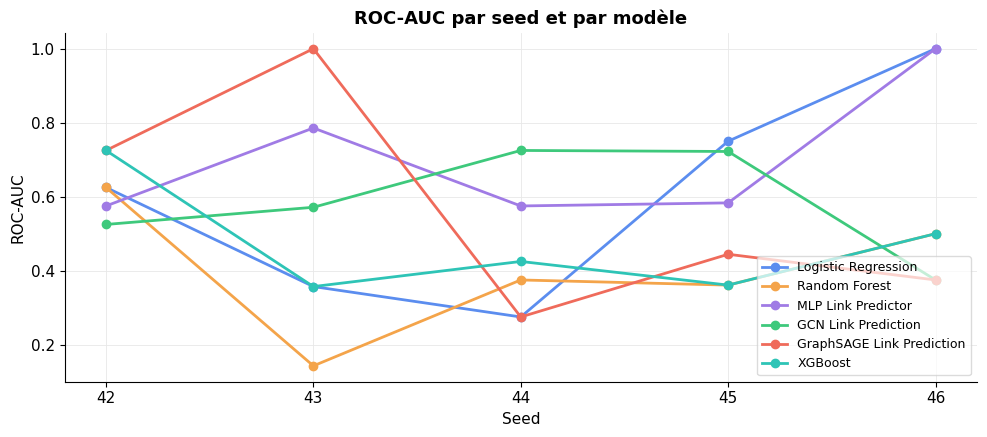

Fig 1 OK


In [36]:

# Figure 1 — Comparaison ROC-AUC par seed (lignes + points)

fig, ax = plt.subplots(figsize=(10, 4.5))
for model in models:
    sub = full_df[full_df["model"] == model].sort_values("seed")
    ax.plot(sub["seed"], sub["roc_auc"],
            marker="o", linewidth=2, markersize=6,
            color=MODEL_COLORS[model], label=model)
ax.set_xlabel("Seed"); ax.set_ylabel("ROC-AUC")
ax.set_title("ROC-AUC par seed et par modèle", fontweight="bold", fontsize=13)
ax.set_xticks(SEEDS)
ax.legend(loc="lower right", fontsize=9, framealpha=0.7)
plt.tight_layout(); plt.savefig(f"{OUTPUT_DIR}/fig1_roc_auc_per_seed.png", dpi=150)
plt.show(); print("Fig 1 OK")

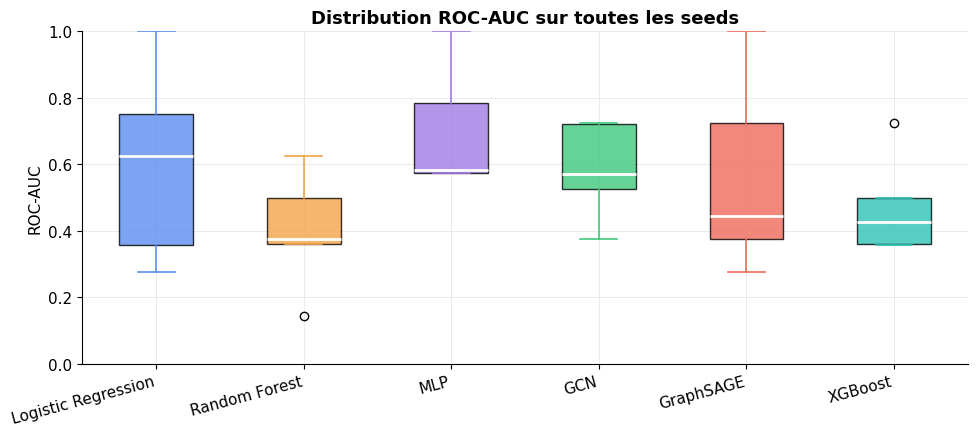

In [37]:
# Figure 2 — Boxplots ROC-AUC (distribution sur les seeds)

fig, ax = plt.subplots(figsize=(10, 4.5))
data_boxes = [full_df[full_df["model"] == m]["roc_auc"].values for m in models]
bp = ax.boxplot(data_boxes, patch_artist=True, widths=0.5,
                medianprops=dict(color="white", linewidth=2))
for patch, model in zip(bp["boxes"], models):
    patch.set_facecolor(MODEL_COLORS[model]); patch.set_alpha(0.8)
for element in ["whiskers","caps","fliers"]:
    for item, model in zip(bp[element], [m for m in models for _ in range(2 if element != "fliers" else 1)]):
        item.set_color(MODEL_COLORS[model]); item.set_linewidth(1.2)
ax.set_xticks(range(1, len(models)+1))
ax.set_xticklabels([m.replace(" Link Prediction","").replace(" Link Predictor","")
                    for m in models], rotation=15, ha="right")
ax.set_ylabel("ROC-AUC"); ax.set_ylim(0, 1)
ax.set_title("Distribution ROC-AUC sur toutes les seeds", fontweight="bold", fontsize=13)
plt.tight_layout(); plt.savefig(f"{OUTPUT_DIR}/fig2_boxplot_roc_auc.png", dpi=150)
plt.show()

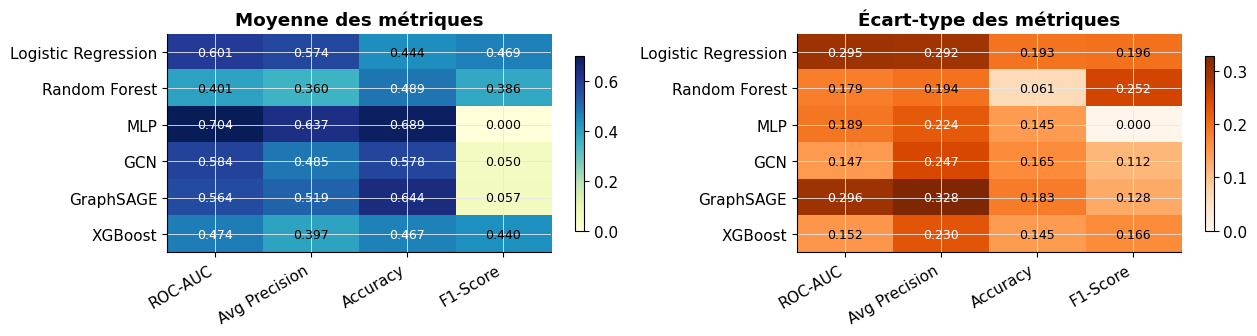

Fig 3 OK


In [38]:

# Figure 3 — Heatmap moyenne ± std (4 métriques × 5 modèles)

fig, axes = plt.subplots(1, 2, figsize=(13, 3.5))
agg = full_df.groupby("model")[METRICS].agg(["mean","std"]).round(4)

for ax, stat, title, cmap in zip(
        axes, ["mean","std"],
        ["Moyenne des métriques", "Écart-type des métriques"],
        ["YlGnBu","Oranges"]):
    mat = pd.DataFrame({m: agg[m][stat] for m in METRICS}, index=models)
    mat.index = [i.replace(" Link Prediction","").replace(" Link Predictor","")
                 for i in mat.index]
    im = ax.imshow(mat.values, aspect="auto", cmap=cmap,
                   vmin=mat.values.min(), vmax=mat.values.max())
    ax.set_xticks(range(len(METRICS)))
    ax.set_xticklabels([METRIC_LABELS[m] for m in METRICS], rotation=30, ha="right")
    ax.set_yticks(range(len(mat))); ax.set_yticklabels(mat.index)
    for i in range(len(mat)):
        for j in range(len(METRICS)):
            ax.text(j, i, f"{mat.values[i,j]:.3f}", ha="center", va="center",
                    fontsize=9, color="white" if mat.values[i,j] > mat.values.max()*0.65 else "black")
    ax.set_title(title, fontweight="bold")
    plt.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout(); plt.savefig(f"{OUTPUT_DIR}/fig3_heatmap_metrics.png", dpi=150)
plt.show(); print("Fig 3 OK")

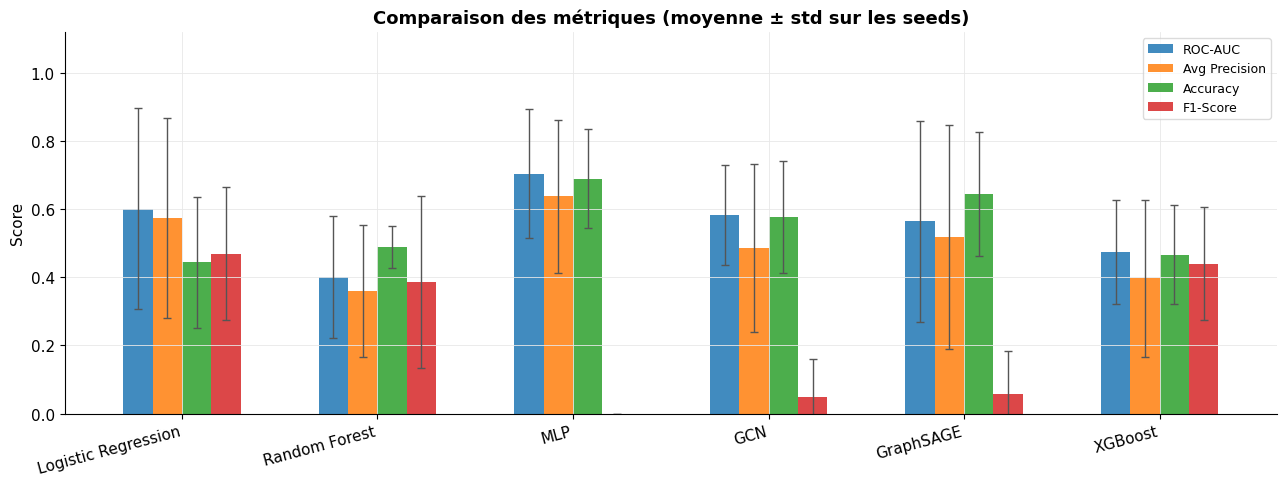

Fig 4 OK


In [39]:

# Figure 4 — Grouped bar chart (toutes métriques, moyenne ± std)

fig, ax = plt.subplots(figsize=(13, 5))
n_metrics = len(METRICS); n_models = len(models)
bar_w = 0.15; x = np.arange(n_models)

for mi, metric in enumerate(METRICS):
    means = [full_df[full_df["model"]==m][metric].mean() for m in models]
    stds  = [full_df[full_df["model"]==m][metric].std()  for m in models]
    offset = (mi - n_metrics/2 + 0.5) * bar_w
    bars = ax.bar(x + offset, means, bar_w, yerr=stds,
                  label=METRIC_LABELS[metric],
                  error_kw=dict(elinewidth=1, capsize=3, capthick=1, ecolor="#555"),
                  alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels([m.replace(" Link Prediction","").replace(" Link Predictor","")
                    for m in models], rotation=15, ha="right")
ax.set_ylabel("Score"); ax.set_ylim(0, 1.12); ax.set_xlim(-0.6, n_models-0.4)
ax.set_title("Comparaison des métriques (moyenne ± std sur les seeds)", fontweight="bold", fontsize=13)
ax.legend(loc="upper right", fontsize=9, framealpha=0.7)
plt.tight_layout(); plt.savefig(f"{OUTPUT_DIR}/fig4_grouped_bar.png", dpi=150)
plt.show(); print("Fig 4 OK")

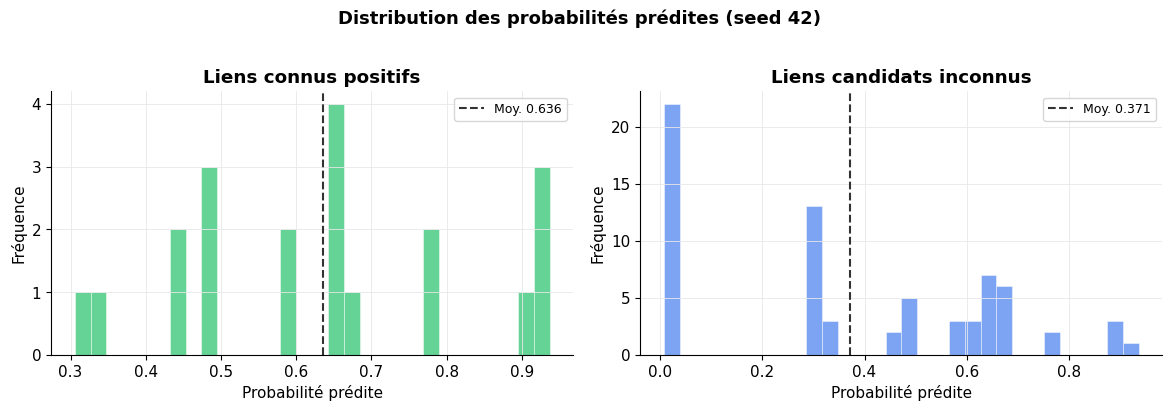

Fig 5 OK


In [40]:

# Figure 5 — Distribution des probabilités prédites (candidats, seed 42)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

reco_seed = all_recommendations[0]  # seed 42

for ax, (known, label, color) in zip(
        axes,
        [(True,  "Liens connus positifs",   "#3EC97C"),
         (False, "Liens candidats inconnus", "#5B8DEF")]):
    sub = reco_seed[reco_seed["known_positive"] == known]["probability"]
    ax.hist(sub, bins=30, color=color, alpha=0.8, edgecolor="white", linewidth=0.4)
    ax.axvline(sub.mean(), color="#333", linestyle="--", linewidth=1.5, label=f"Moy. {sub.mean():.3f}")
    ax.set_xlabel("Probabilité prédite"); ax.set_ylabel("Fréquence")
    ax.set_title(label, fontweight="bold")
    ax.legend(fontsize=9)
plt.suptitle("Distribution des probabilités prédites (seed 42)", fontweight="bold", fontsize=13, y=1.02)
plt.tight_layout(); plt.savefig(f"{OUTPUT_DIR}/fig5_prob_distribution.png", dpi=150)
plt.show(); print("Fig 5 OK")

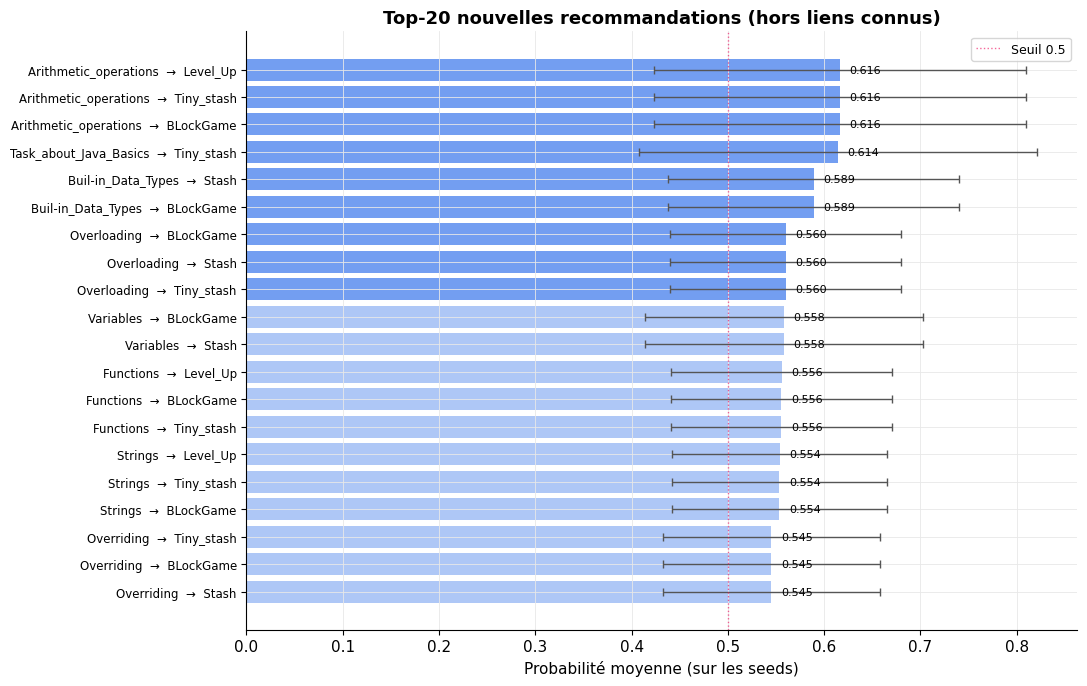

Fig 6 OK


In [41]:

# Figure 6 — Top-20 recommandations agrégées (barh)

fig, ax = plt.subplots(figsize=(11, 7))
top20 = (agg_reco_df[~agg_reco_df["known_positive"]]
         .head(20)
         .sort_values("probability_mean"))
labels = [f"{r['source'][:22]}  →  {r['target'][:22]}" for _, r in top20.iterrows()]
colors = ["#5B8DEF" if p > top20["probability_mean"].median() else "#A0BEF5"
          for p in top20["probability_mean"]]
bars = ax.barh(range(len(top20)), top20["probability_mean"], xerr=top20["probability_std"],
               color=colors, alpha=0.85, error_kw=dict(elinewidth=1, capsize=3, ecolor="#555"))
ax.set_yticks(range(len(top20))); ax.set_yticklabels(labels, fontsize=8.5)
ax.set_xlabel("Probabilité moyenne (sur les seeds)")
ax.set_title(f"Top-20 nouvelles recommandations (hors liens connus)", fontweight="bold", fontsize=13)
ax.axvline(0.5, color="#E05", linestyle=":", linewidth=1, alpha=0.6, label="Seuil 0.5")
ax.legend(fontsize=9)
for bar, p in zip(bars, top20["probability_mean"]):
    ax.text(min(p + 0.01, 0.98), bar.get_y() + bar.get_height()/2,
            f"{p:.3f}", va="center", fontsize=8)
plt.tight_layout(); plt.savefig(f"{OUTPUT_DIR}/fig6_top20_recommendations.png", dpi=150)
plt.show(); print("Fig 6 OK")

## 12. Sauvegarde

In [42]:
full_results_df.to_csv(f"{OUTPUT_DIR}/all_seeds_results.csv", index=False)
summary_df.to_csv(f"{OUTPUT_DIR}/model_comparison_summary.csv", index=False)
agg_reco_df.to_csv(f"{OUTPUT_DIR}/best_model_all_predictions.csv", index=False)
topk_recommendations.to_csv(f"{OUTPUT_DIR}/best_model_topk_recommendations.csv", index=False)

with open(f"{OUTPUT_DIR}/model_comparison.json","w") as f:
    json.dump(all_seed_results, f, indent=2)

print(f"Fichiers sauvegardés dans : {OUTPUT_DIR}/")

Fichiers sauvegardés dans : task2/outputs_task2_multimodel/
